In [1]:
# What is happening in this business and what should we do about it?
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# Read raw E-commerce CSV, encoding allows for reading of GBP
df = pd.read_csv(r"C:\Users\YawOM\OneDrive\Desktop\Data Science\UK_E-Commerce.csv", encoding='ISO-8859-1')

In [3]:
# Load the databbase in
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [4]:
# Gain info on columns on table
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Look for general info on the table
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
#Discover any rows that has missing units
df[df.isna().any(axis=1)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [7]:
# Convert the InvoiceDate into the datetime data type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
# Generate the total price column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [9]:
# create connection to database file, save dataframe to database file
conn = sqlite3.connect("ecommerce.db")
df.to_sql("UK_E-Commerce.csv", conn, if_exists = "replace", index = False)

541909

In [10]:
# Calculate revenue in millions
query = """ SELECT Sum(Revenue) / 1000000 AS Revenue_millions FROM "UK_E-Commerce.csv" """
pd.read_sql(query, conn)

,Revenue_millions
0,9.747748


In [11]:
# Calculate average revenue per order
query2 = """ SELECT AVG(Revenue) AS Avg_Order_Revenue FROM "UK_E-Commerce.csv" """
pd.read_sql(query2, conn)

,Avg_Order_Revenue
0,17.987795


In [12]:
# Calculate the amount of orders stored in table
query3 = """ SELECT COUNT(*) AS Order_Count FROM "UK_E-Commerce.csv" """
pd.read_sql(query3, conn)

,Order_Count
0,541909


In [13]:
# Find te individual items and display total revenue generated
query4 = """ SELECT Description, SUM(Revenue) AS Total_Order_Revenue FROM "UK_E-Commerce.csv" GROUP BY Description ORDER BY SUM(Revenue) DESC"""
pd.read_sql(query4, conn)

,Description,Total_Order_Revenue
0,DOTCOM POSTAGE,206245.480
1,REGENCY CAKESTAND 3 TIER,164762.190
2,WHITE HANGING HEART T-LIGHT HOLDER,99668.470
3,PARTY BUNTING,98302.980
4,JUMBO BAG RED RETROSPOT,92356.030
...,...,...
4219,Bank Charges,-7175.639
4220,CRUK Commission,-7933.430
4221,Adjust bad debt,-11062.060
4222,Manual,-68671.640


In [14]:
# Calculate the amount of total revenue per month
query5 = """ SELECT strftime("%Y-%m", InvoiceDate) AS YearMonth, SUM(Revenue) AS Total_Revenue FROM "UK_E-Commerce.csv" GROUP BY YearMonth ORDER BY YearMonth ASC """
monthly_rev = pd.read_sql(query5, conn)
monthly_rev.set_index("YearMonth", inplace = True)
monthly_rev

,Total_Revenue
YearMonth,
2010-12,748957.020
2011-01,560000.260
2011-02,498062.650
2011-03,683267.080
2011-04,493207.121
2011-05,723333.510
2011-06,691123.120
2011-07,681300.111
2011-08,682680.510


In [15]:
# Calculate the revenue generated per week
query6 = """ SELECT strftime('%Y-%W', InvoiceDate) AS YearWeek, SUM(Revenue) AS Total_Revenue FROM "UK_E-Commerce.csv" GROUP BY YearWeek ORDER BY YearWeek ASC """
week_rev = pd.read_sql(query6, conn)
week_rev.set_index("YearWeek", inplace = True)
week_rev

,Total_Revenue
YearWeek,
2010-48,181847.250
2010-49,270287.030
2010-50,207052.170
2010-51,89770.570
2011-01,93720.930
2011-02,190994.960
2011-03,133782.910
2011-04,119136.810
2011-05,123642.180


In [16]:
# Calculate the total revenue generated by each day of business overtime
query7 = """ SELECT strftime('%w', InvoiceDate) AS Weekday, SUM(Revenue) AS Total_Revenue FROM "UK_E-Commerce.csv" GROUP BY Weekday ORDER BY Weekday ASC """
daily_rev = pd.read_sql(query7, conn)
daily_rev = daily_rev.replace({"Weekday": {"0":"Monday", "1":"Tuesday", "2":"Wednesday", "3":"Thursday", "4":"Friday", "5":"Saturday"}})
daily_rev.set_index("Weekday", inplace = True)
daily_rev

,Total_Revenue
Weekday,
Monday,805678.891
Tuesday,1588609.431
Wednesday,1966182.791
Thursday,1734147.010
Friday,2112519.000
Saturday,1540610.811


In [17]:
# Search for the top 5 sources of revenue
query8 = """ SELECT Description, SUM(Revenue) AS Avg_Order_Revenue FROM "UK_E-Commerce.csv" GROUP BY Description ORDER BY SUM(Revenue) DESC LIMIT 5 """
top5_revenue = pd.read_sql(query8, conn)
top5_revenue.set_index("Description", inplace = True)
top5_revenue

,Avg_Order_Revenue
Description,
DOTCOM POSTAGE,206245.48
REGENCY CAKESTAND 3 TIER,164762.19
WHITE HANGING HEART T-LIGHT HOLDER,99668.47
PARTY BUNTING,98302.98
JUMBO BAG RED RETROSPOT,92356.03


In [18]:
# Search the top 5 sources of negative revenue
query9 = """ SELECT Description, SUM(Revenue) AS Avg_Order_Revenue FROM "UK_E-Commerce.csv" GROUP BY Description ORDER BY SUM(Revenue) ASC LIMIT 5 """
bot5_revenue = pd.read_sql(query9, conn)
bot5_revenue.set_index("Description", inplace = True)
bot5_revenue

,Avg_Order_Revenue
Description,
AMAZON FEE,-221520.500
Manual,-68671.640
Adjust bad debt,-11062.060
CRUK Commission,-7933.430
Bank Charges,-7175.639


In [19]:
# Calculate revenue / 10^6
query10 = """ SELECT Sum(Revenue) AS Revenue FROM "UK_E-Commerce.csv" """
pd.read_sql(query10, conn)

,Revenue
0,9.747748e+06


In [20]:
# Calculate the top 20% of products that generate income for the company
query11 = """ SELECT Description, (SUM(Revenue) / 9747748) * 100 AS Revenue_Pct FROM "UK_E-Commerce.csv" GROUP BY Description ORDER BY Revenue_Pct DESC LIMIT 844 OFFSET 1 """
top20_pct = pd.read_sql(query11, conn)
top20_pct

,Description,Revenue_Pct
0,REGENCY CAKESTAND 3 TIER,1.690259
1,WHITE HANGING HEART T-LIGHT HOLDER,1.022477
2,PARTY BUNTING,1.008469
3,JUMBO BAG RED RETROSPOT,0.947460
4,RABBIT NIGHT LIGHT,0.684841
...,...,...
839,PACK OF 12 HEARTS DESIGN TISSUES,0.028085
840,BLUE POLKADOT WRAP,0.028082
841,SMALL HEART MEASURING SPOONS,0.028059
842,SINGLE ANTIQUE ROSE HOOK IVORY,0.028041


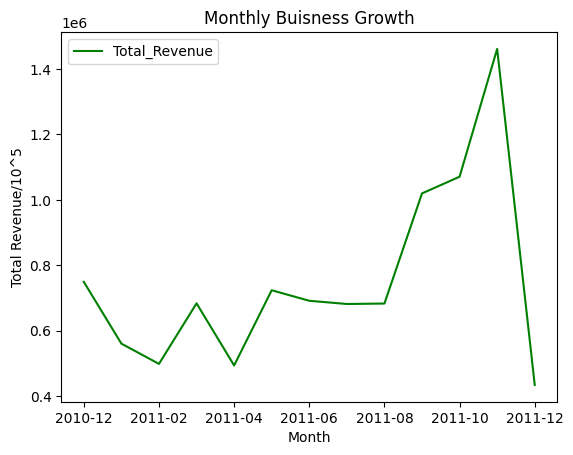

In [21]:
# Make a line graph visualising growth or decline or revenue overtime
fig, ax1 = plt.subplots()

monthly_rev.plot(kind = 'line', ax = ax1, color = 'green')
ax1.set_title('Monthly Buisness Growth')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Revenue/10^5')

plt.show()

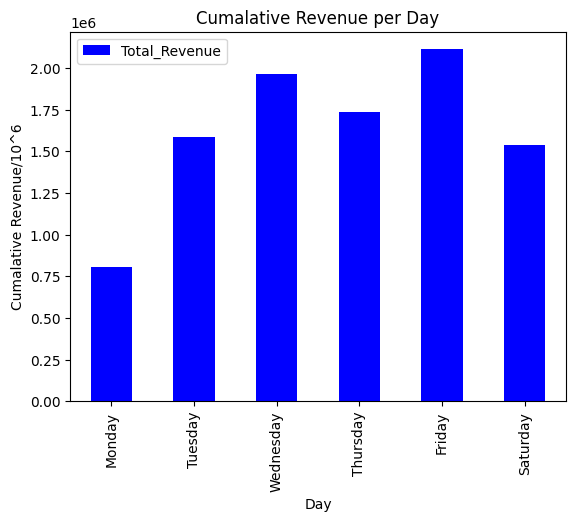

In [22]:
# Create a bar chart to visualise which business days generated the most revenue for the company overtime
fig, ax2 = plt.subplots()

daily_rev.plot(kind = "bar", ax = ax2, color = "blue")
ax2.set_title("Cumalative Revenue per Day")
ax2.set_xlabel("Day")
ax2.set_ylabel("Cumalative Revenue/10^6")

plt.show()

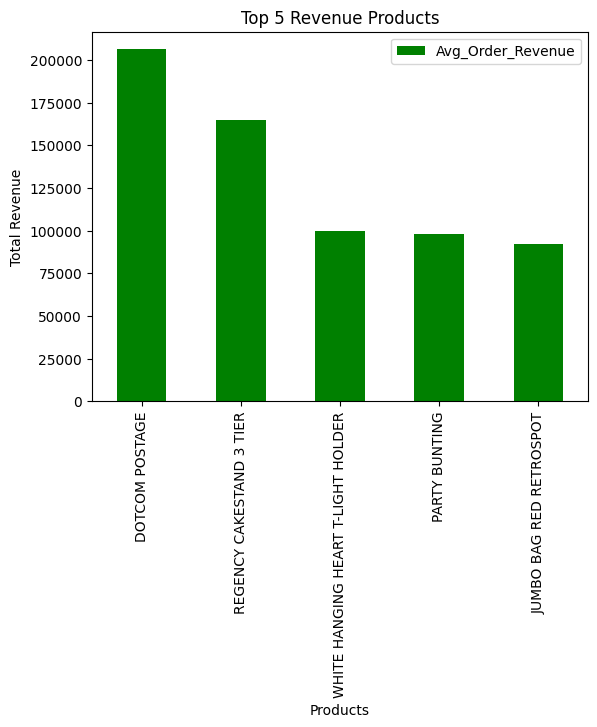

In [23]:
# Create a bar chart visualising the amount of revenue the top 5 "products" generated for the company over time.
fig, ax3 = plt.subplots()

top5_revenue.plot(kind = "bar", ax = ax3, color = "green")
ax3.set_title("Top 5 Revenue Products")
ax3.set_xlabel("Products")
ax3.set_ylabel("Total Revenue")

plt.show()

In [24]:
monthly_rev.to_csv("C:/Users/YawOM/OneDrive/Desktop/Data Science/monthly_rev.csv")
daily_rev.to_csv("C:/Users/YawOM/OneDrive/Desktop/Data Science/daily_rev.csv")
top5_revenue.to_csv("C:/Users/YawOM/OneDrive/Desktop/Data Science/top5_revenue.csv")